In [1]:
import sys
!{sys.executable} -m pip install pytorch-lightning -i https://pypi.tuna.tsinghua.edu.cn/simple


Looking in indexes: https://pypi.tuna.tsinghua.edu.cn/simple


In [3]:
import os
import torch
import matplotlib.pyplot as plt
import pytorch_lightning as pl
from torch.optim import lr_scheduler
import segmentation_models_pytorch as smp
from torch.utils.data import DataLoader

class PathModel(pl.LightningModule):
    def __init__(self, arch, encoder_name, in_channels, out_classes, **kwargs):
        super().__init__()
        self.model = smp.create_model(
            arch,
            encoder_name=encoder_name,
            in_channels=in_channels,
            classes=out_classes,
            **kwargs,
        )
        # preprocessing parameteres for image
        params = smp.encoders.get_preprocessing_params(encoder_name)
        self.register_buffer("std", torch.tensor(params["std"]).view(1, 3, 1, 1))
        self.register_buffer("mean", torch.tensor(params["mean"]).view(1, 3, 1, 1))

        # for image segmentation dice loss could be the best first choice
        self.loss_fn = smp.losses.DiceLoss(smp.losses.MULTICLASS_MODE, from_logits=True)

        # initialize step metics
        self.training_step_outputs = []
        self.validation_step_outputs = []
        self.test_step_outputs = []

    def forward(self, image):
        # normalize image here
        image = (image - self.mean) / self.std
        mask = self.model(image)
        return mask

    def shared_step(self, batch, stage):
        image = batch["image"]
        assert image.ndim == 4

        h, w = image.shape[2:]
        assert h % 32 == 0 and w % 32 == 0

        mask = batch["mask"]
        assert mask.ndim == 4

        # ========== 二分类mask范围断言 ==========
        # assert mask.max() <= 1.0 and mask.min() >= 0

        logits_mask = self.forward(image)

        # 取出 \[B,1,H,W\] → \[B,H,W\] 浮点图
        mask_float = mask.squeeze(1)
        # 新建整数标签容器
        mask_gt = torch.zeros_like(mask_float, dtype=torch.long)

        # 区间映射：0=背景，1=天空，2=道路
        mask_gt[mask_float < 0.2] = 0
        mask_gt[(mask_float >= 0.2) & (mask_float < 0.8)] = 1
        mask_gt[mask_float >= 0.8] = 2

        loss = self.loss_fn(logits_mask, mask_gt)

        # ========== 二分类sigmoid阈值预测，多分类argmax ==========
        # prob_mask = logits_mask.sigmoid()
        # pred_mask = (prob_mask > 0.5).float()
        pred_mask = torch.argmax(logits_mask, dim=1)  # [B,3,H,W] -> [B,H,W]
        tp, fp, fn, tn = smp.metrics.get_stats(
            pred_mask.long(),
            mask_gt,
            mode="multiclass",
            num_classes=OUT_CLASSES
        )
        return {
            "loss": loss,
            "tp": tp,
            "fp": fp,
            "fn": fn,
            "tn": tn,
        }


    def shared_epoch_end(self, outputs, stage):
        # aggregate step metics
        tp = torch.cat([x["tp"] for x in outputs])
        fp = torch.cat([x["fp"] for x in outputs])
        fn = torch.cat([x["fn"] for x in outputs])
        tn = torch.cat([x["tn"] for x in outputs])

        # per image IoU means that we first calculate IoU score for each image
        # and then compute mean over these scores
        per_image_iou = smp.metrics.iou_score(
            tp, fp, fn, tn, reduction="micro-imagewise"
        )

        # dataset IoU means that we aggregate intersection and union over whole dataset
        # and then compute IoU score. The difference between dataset_iou and per_image_iou scores
        # in this particular case will not be much, however for dataset
        # with "empty" images (images without target class) a large gap could be observed.
        # Empty images influence a lot on per_image_iou and much less on dataset_iou.
        dataset_iou = smp.metrics.iou_score(tp, fp, fn, tn, reduction="micro")
        metrics = {
            f"{stage}_per_image_iou": per_image_iou,
            f"{stage}_dataset_iou": dataset_iou,
        }

        self.log_dict(metrics, prog_bar=True)

    def training_step(self, batch, batch_idx):
        train_loss_info = self.shared_step(batch, "train")
        # append the metics of each step to the
        self.training_step_outputs.append(train_loss_info)
        return train_loss_info

    def on_train_epoch_end(self):
        self.shared_epoch_end(self.training_step_outputs, "train")
        # empty set output list
        self.training_step_outputs.clear()
        return

    def validation_step(self, batch, batch_idx):
        valid_loss_info = self.shared_step(batch, "valid")
        self.validation_step_outputs.append(valid_loss_info)
        return valid_loss_info

    def on_validation_epoch_end(self):
        self.shared_epoch_end(self.validation_step_outputs, "valid")
        self.validation_step_outputs.clear()
        return

    def test_step(self, batch, batch_idx):
        test_loss_info = self.shared_step(batch, "test")
        self.test_step_outputs.append(test_loss_info)
        return test_loss_info

    def on_test_epoch_end(self):
        self.shared_epoch_end(self.test_step_outputs, "test")
        # empty set output list
        self.test_step_outputs.clear()
        return

    def configure_optimizers(self):
        optimizer = torch.optim.Adam(self.parameters(), lr=2e-4)
        scheduler = lr_scheduler.CosineAnnealingLR(optimizer, T_max=T_MAX, eta_min=1e-5)
        return {
            "optimizer": optimizer,
            "lr_scheduler": {
                "scheduler": scheduler,
                "interval": "step",
                "frequency": 1,
            },
        }
        return




In [4]:
# 路径换成你的权重文件
os.environ["CUDA_VISIBLE_DEVICES"] = "-1"
ckpt_path = "./model-epoch-epoch=02.ckpt"

# 构造和训练完全一样的参数：linknet, resnet18, 3通道, 3分类
model = PathModel.load_from_checkpoint(
    checkpoint_path=ckpt_path,
    arch="linknet",
    encoder_name="resnet18",
    in_channels=3,
    out_classes=3
)
# 推理模式
model.eval()
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model.to(device)






PathModel(
  (model): Linknet(
    (encoder): ResNetEncoder(
      (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
      (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
      (layer1): Sequential(
        (0): BasicBlock(
          (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
          (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
          (relu): ReLU(inplace=True)
          (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
          (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        )
        (1): BasicBlock(
          (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
          (bn1): Ba

In [5]:
root_path="/home/luweijie/Desktop/毕业/实习/ORFD"
test_img_dir = os.path.join(root_path,"testing","image_data")
test_mask_dir = os.path.join(root_path,"testing","gt_image")
count_test_img = len(os.listdir(test_img_dir))
count_test_mask = len(os.listdir(test_mask_dir))
print("===== 数据集数量统计 =====")
print(f"测试集原图数量：{count_test_img}")
print(f"测试集掩码数量：{count_test_mask}")


===== 数据集数量统计 =====
测试集原图数量：2193
测试集掩码数量：2193


In [ ]:
import sys
!{sys.executable} -m pip install albumentations -i https://pypi.tuna.tsinghua.edu.cn/simple


In [6]:
import os
import cv2
import torch
from torch.utils.data import Dataset
import albumentations as A
from albumentations.pytorch import ToTensorV2
from PIL import Image
import numpy as np
# 自定义分割数据集类
class SegDataset(Dataset):
    def __init__(self, img_dir, mask_dir):
        self.img_dir = img_dir
        self.mask_dir = mask_dir
        # 获取所有原图文件名
        self.img_names = sorted([f for f in os.listdir(img_dir)
                                 if f.endswith((".jpg", ".png", ".jpeg"))])

    def __len__(self):
        return len(self.img_names)

    def __getitem__(self, idx):
        img_name = self.img_names[idx]
        img_path = os.path.join(self.img_dir, img_name)

        # 提取纯文件名，mask统一png
        file_stem = os.path.splitext(img_name)[0]
        mask_name = f"{file_stem}_fillcolor.png"
        mask_path = os.path.join(self.mask_dir, mask_name)

        # 读图
        image = Image.open(img_path).convert("RGB")
        mask = Image.open(mask_path).convert("L")

        image = np.array(image, dtype=np.float32)/255
        mask = np.array(mask, dtype=np.float32)/255

        return {
            "image": image,
            "mask": mask,
            "stem": file_stem
        }
# 你的全局路径
import torch
import torchvision.transforms as T

TARGET_SIZE = (320, 640)
BATCH_SIZE=16
NUM_WORKERS=2
def seg_collate_fn(batch):
    img_list = []
    mask_list = []
    for item in batch:
        img_np = item["image"]
        mask_np = item["mask"]

        # HWC numpy 转 CHW tensor
        img_tensor = torch.from_numpy(img_np).permute(2, 0, 1)
        mask_tensor = torch.from_numpy(mask_np).unsqueeze(0) # [1,H,W]

        # 统一缩放
        img_resize = T.Resize(TARGET_SIZE)(img_tensor)
        mask_resize = T.Resize(TARGET_SIZE, interpolation=T.InterpolationMode.NEAREST)(mask_tensor)

        img_list.append(img_resize)
        mask_list.append(mask_resize)

    return {
        "image": torch.stack(img_list),
        "mask": torch.stack(mask_list)
    }

root_path="/home/luweijie/Desktop/毕业/实习/ORFD"
test_ds = SegDataset(test_img_dir, test_mask_dir)
test_loader = DataLoader(
    test_ds,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=NUM_WORKERS,
    collate_fn=seg_collate_fn

)

/home/luweijie/Desktop/图像处理/图像处理环境/lib/python3.10/site-packages/albumentations/check_version.py:147: UserWarning: Error fetching version info <urlopen error _ssl.c:990: The handshake operation timed out>
  data = fetch_version_info()


pred_mask 最小值： 0
pred_mask 最大值： 2
图像中存在的类别： [0 1 2]


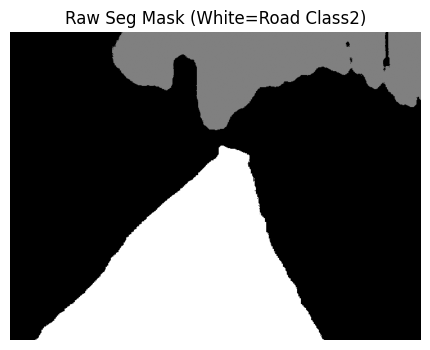

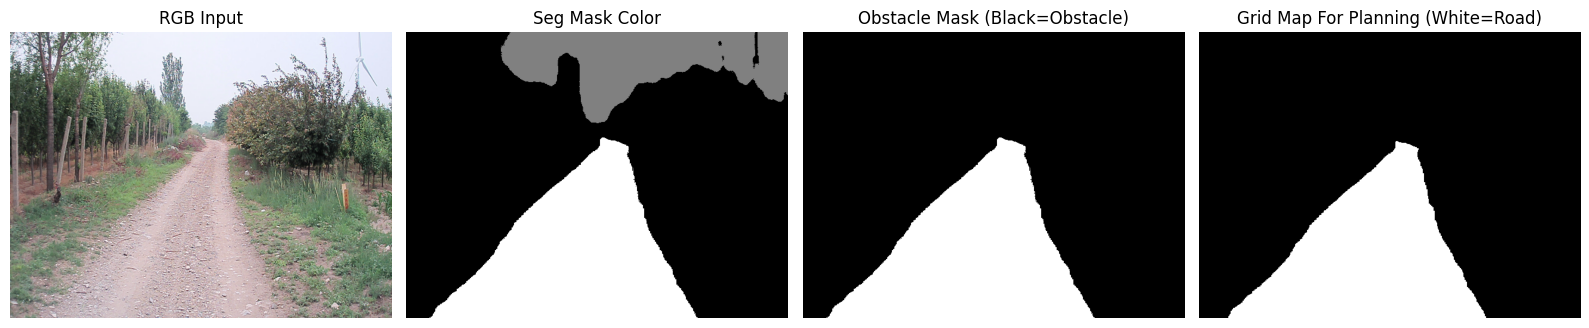

栅格可视化保存至：./predict_vis/grid_result.png


In [7]:
import torch
import numpy as np
import matplotlib.pyplot as plt
import os
import cv2
from PIL import Image

# 新建保存文件夹
save_dir = "./predict_vis"
os.makedirs(save_dir, exist_ok=True)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model.eval()
model.to(device)

# -------------------------- 配置参数 --------------------------
img_path = "./test/330.png"   # 测试图片路径
img_size = (640, 480)    # 模型输入尺寸
num_classes = 3          # 3个类别
dilate_kernel_size = 5   # 障碍物膨胀核大小

# 3分类调色板（更新：2是道路白色）
class_colors = np.array([
    [0, 0, 0],        # 0 背景
    [128, 128, 128],  # 1 天空
    [255, 255, 255],  # 2 道路（可通行）
], dtype=np.uint8)
# ---------------------------------------------------------------

# 1. 读取图像并预处理
img_pil = Image.open(img_path).convert("RGB")
img_resized = img_pil.resize(img_size)

# 转模型输入tensor
img_np = np.array(img_resized, dtype=np.float32) / 255.0
img_tensor = torch.from_numpy(img_np).permute(2, 0, 1).unsqueeze(0).to(device)

# 2. 推理预测
with torch.no_grad():
    pred = model(img_tensor)  # [1, 3, H, W]
    pred_mask = torch.argmax(pred, dim=1).squeeze(0).cpu().numpy()  # [H, W]

# 防止索引越界
pred_mask = np.clip(pred_mask, 0, num_classes - 1)

# ========== 查看原始分割图 ==========
print("pred_mask 最小值：", pred_mask.min())
print("pred_mask 最大值：", pred_mask.max())
print("图像中存在的类别：", np.unique(pred_mask))

plt.figure(figsize=(6,4))
plt.title("Raw Seg Mask (White=Road Class2)")
plt.imshow(pred_mask, cmap="gray")
plt.axis("off")
plt.show()
# ================================================

# ---------------------- 生成栅格地图 ----------------------
# 原始障碍掩码：不是道路(2)的全部视为障碍
raw_obs = (pred_mask != 2).astype(np.uint8)
# Obstacle Mask：黑色=障碍，白色=道路
obs_mask = 1 - raw_obs

# 可行区域：类别2道路
free_mask = (pred_mask == 2).astype(np.uint8)

# 障碍物膨胀
kernel = cv2.getStructuringElement(cv2.MORPH_RECT, (dilate_kernel_size, dilate_kernel_size))
obs_dilate = cv2.dilate(raw_obs, kernel, iterations=2)

# 规划栅格：1=白色道路可走，0=黑色障碍
grid_map = np.zeros_like(free_mask)
grid_map[free_mask == 1] = 1
grid_map[obs_dilate == 1] = 0
# ---------------------------------------------------------

# 彩色分割图
color_mask = class_colors[pred_mask]
img_vis = np.array(img_resized)

# 四张子图展示
plt.figure(figsize=(16, 4))

plt.subplot(1, 4, 1)
plt.title("RGB Input")
plt.imshow(img_vis)
plt.axis("off")

plt.subplot(1, 4, 2)
plt.title("Seg Mask Color")
plt.imshow(color_mask)
plt.axis("off")

plt.subplot(1, 4, 3)
plt.title("Obstacle Mask (Black=Obstacle)")
plt.imshow(obs_mask, cmap="gray")
plt.axis("off")

plt.subplot(1, 4, 4)
plt.title("Grid Map For Planning (White=Road)")
plt.imshow(grid_map, cmap="gray")
plt.axis("off")

plt.tight_layout()
save_path = os.path.join(save_dir, "grid_result.png")
plt.savefig(save_path, dpi=150, bbox_inches="tight")
plt.show()

print(f"栅格可视化保存至：{save_path}")


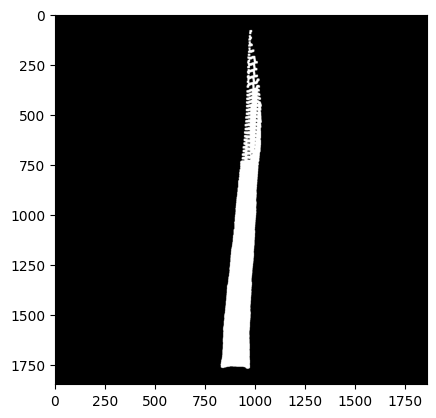

In [8]:
import numpy as np
import cv2
import matplotlib.pyplot as plt

# 参数
depth_path = "./test/d330.png"
fx, fy = 1472.919866, 1452.953534
cx, cy = 614.779599, 353.800982
depth_scale = 1000

# 读深度
D = cv2.imread(depth_path, cv2.IMREAD_UNCHANGED)
H, W = D.shape

# mask=1 道路
mask = cv2.resize(grid_map, (1280, 640), interpolation=cv2.INTER_NEAREST)

# 只拿mask=1像素
v_road, u_road = np.where(mask == 1)
depth_mm = D[v_road, u_road]
valid = depth_mm > 0
u = u_road[valid]
v = v_road[valid]
d = depth_mm[valid] / depth_scale

# 批量计算相机坐标系 Xc,Yc,Zc
Xc = (u - cx) * d / fx
Yc = (v - cy) * d / fy
Zc = d
import numpy as np
import cv2
import matplotlib.pyplot as plt

# 绘制并保存散点图
plt.figure(figsize=(8,8))
plt.scatter(Xc, Zc, s=1, c="red")
plt.axis("equal")
plt.axis('off')
plt.savefig("scatter_xz.png", dpi=300, bbox_inches="tight", pad_inches=0)
plt.close()

# 读取图像转灰度
img = cv2.imread("scatter_xz.png")
gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

# 二值反转：红点变白，背景黑
_, scatter_mask = cv2.threshold(gray, 100, 255, cv2.THRESH_BINARY_INV)

# 1. 膨胀填充点之间空隙
kernel_dilate = cv2.getStructuringElement(cv2.MORPH_RECT, (4,4))
scatter_mask = cv2.dilate(scatter_mask, kernel_dilate, iterations=2)

# 2. 腐蚀，收缩边缘，还原轮廓粗细
kernel_erode = cv2.getStructuringElement(cv2.MORPH_RECT, (3,3))
scatter_mask = cv2.erode(scatter_mask, kernel_erode, iterations=1)
plt.figure()
plt.imshow(scatter_mask, cmap="gray")
plt.show()



In [12]:
import numpy as np

h, w = scatter_mask.shape
y_all, x_all = np.where(scatter_mask == 255)

# 最底部的1
idx_bottom = np.argmax(y_all)
y_bottom = y_all[idx_bottom]


target_y = y_bottom-10
row_mask = y_all == target_y
row_xs = x_all[row_mask].mean()

finall_y = y_bottom-700
finall_mask = y_all == finall_y
finall_xs = x_all[finall_mask].mean()
target_pt = (row_xs, target_y)
finall_pt = (finall_xs, finall_y)
print("目标点(x该行均值, y_bottom-10)：", target_pt)
print(finall_pt)



目标点(x该行均值, y_bottom-10)： (np.float64(905.1428571428571), np.int64(1761))
(np.float64(948.0), np.int64(1071))


In [51]:
scatter_mask.shape

(1848, 1860)

In [45]:
import sys
!{sys.executable} -m pip install pathfinding -i https://pypi.tuna.tsinghua.edu.cn/simple



Looking in indexes: https://pypi.tuna.tsinghua.edu.cn/simple


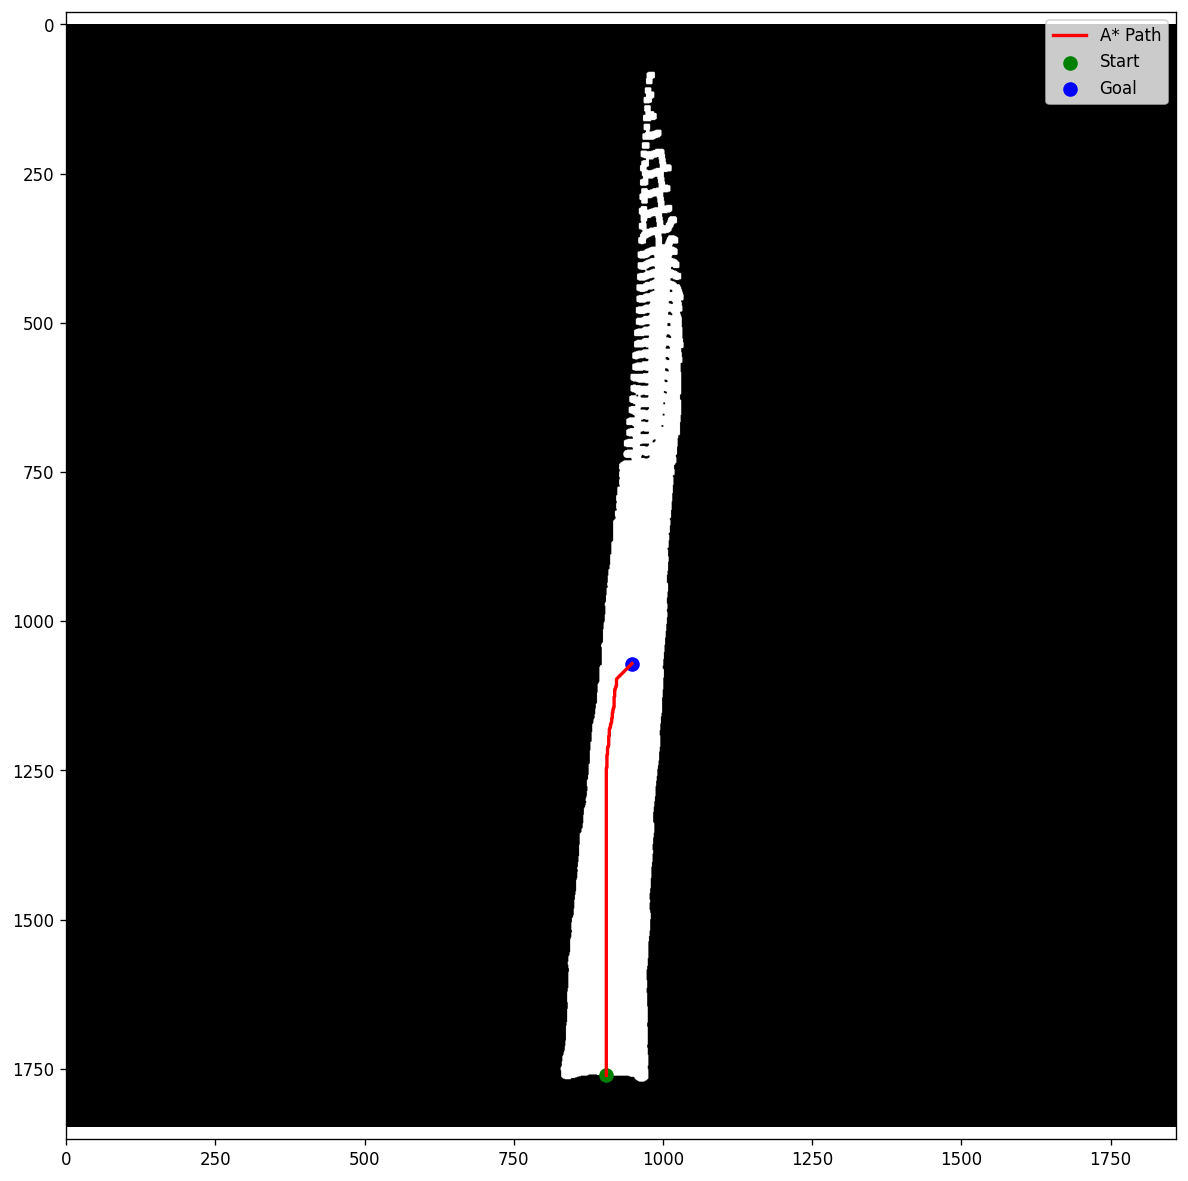

In [15]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.ndimage import distance_transform_edt
# 寻路库导入
from pathfinding.core.grid import Grid
from pathfinding.core.diagonal_movement import DiagonalMovement

obs_mask = (scatter_mask == 0)

dist_to_obs = distance_transform_edt(~obs_mask)

weight_mat = np.where(dist_to_obs < 3, 10, 1)
weight_mat[dist_to_obs < 30] += 5
weight_mat = weight_mat.tolist()

# ---------------------- 3. 初始化寻路 ----------------------
sx=int(row_xs)
sy=target_y
gx=int(finall_xs)
gy=finall_y
grid = Grid(matrix=weight_mat)
start_node = grid.node(sx,sy)
end_node = grid.node(gx,gy)
from pathfinding.finder.a_star import AStarFinder
from pathfinding.core.diagonal_movement import DiagonalMovement

# always=八向移动 never=四向移动
finder = AStarFinder(diagonal_movement=DiagonalMovement.always)

path_nodes, _ = finder.find_path(start_node, end_node, grid)
import numpy as np

from scipy.ndimage import gaussian_filter1d

def smooth_path(x_list, y_list, sigma=1.5):
    pts_num = len(x_list)
    if pts_num <= 3:
        return x_list, y_list
    x = np.array(x_list, dtype=np.float32)
    y = np.array(y_list, dtype=np.float32)
    x_smooth = gaussian_filter1d(x, sigma=sigma)
    y_smooth = gaussian_filter1d(y, sigma=sigma)
    return x_smooth.tolist(), y_smooth.tolist()

# 使用
path_x = [p.x for p in path_nodes]
path_y = [p.y for p in path_nodes]
#path_x, path_y = smooth_path(path_x, path_y, sigma=2.8)

# ---------------------- 4. 绘图（可行区白色，障碍黑色） ----------------------
plt.figure(figsize=(10, 10), dpi=120)
plt.imshow(scatter_mask, cmap="gray", origin="upper")
plt.plot(path_x, path_y, c="red", lw=2, label="A* Path")
plt.scatter(sx, sy, c="green", s=60, label="Start")
plt.scatter(gx, gy, c="blue", s=60, label="Goal")
plt.legend()
plt.axis("equal")
plt.tight_layout()
plt.show()


In [51]:
import pathfinding
import os
# 打印库根目录
print(pathfinding.__path__)
# 查看finder文件夹下所有文件
finder_dir = os.path.join(pathfinding.__path__[0], "finder")
print("finder目录内容：", os.listdir(finder_dir))


['/home/luweijie/Desktop/图像处理/图像处理环境/lib/python3.10/site-packages/pathfinding']
finder目录内容： ['bi_best_first.py', 'ida_star.py', 'bi_breadth_first.py', 'a_star.py', '__pycache__', 'bi_a_star.py', 'best_first.py', 'msp.py', 'dijkstra.py', '__init__.py', 'finder.py', 'bi_dijkstra.py', 'breadth_first.py']
